In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

FIG_DIR_ROOT = PROJECT_ROOT / "figures" / "arctic_amplification/65n"

In [8]:
import os
import glob
from pathlib import Path
import json
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional

In [50]:
class ArcticAAPlotter:
    """
    Plot AA time series and show summary statistics produced by ArcticAAProcessor.

    Expected files (from ArcticAAProcessor.run_and_save):
      AA2_{EXP}_{ANCHOR}_ts_{GROUP}_{VAR}_{SEASON}_{PTARGT0}-{PTARGT1}_{WIN}yr_{ANCHOR}.nc
      AA2_{EXP}_{ANCHOR}_ts_{GROUP}_{VAR}_{SEASON}_{PTARGT0}-{PTARGT1}_{WIN}yr_{ANCHOR}.json

    Examples of prefixes (everything before SEASON):
      "AA2_ERA5_center_ts_ERA5_TS"
      "AA2_E3SMv3-LE_center_ts_v3.LR.historical_TS"

    Features:
      - understands anchors: 'center' | 'start' | 'end'
      - prefers fixed processor axis 'time_year' / 'time_label_year'
      - DOES NOT trim to obs–model overlap (model can extend beyond ERA5)
      - loads and prints stats from the paired JSON
      - optional member spaghetti overlay for model
      - stats box layout selectable: "split" (two boxes) or "single"

    NEW:
      - plot_seasons_grid can show one-obs+model or two-obs+model (ERA5 red, NOAA-20C pink)
      - plot_metrics_timeseries_tripanel: AA, beta_Arctic, beta_Global sliding-window time series
    """

    def __init__(
        self,
        *,
        fig_dir,
        out_dir,
        ptargt=(1979, 2018),
        trend_window=30,
        trend_anchor="center",
        var="TS",
        pattern=None,
        verbose=True,
        show_ref_line=True,
        ref_value=2.0,
        color_obs="red",          # primary obs (ERA5) → red
        color_mean="k",           # model ensemble mean
        color_members="gray",     # model members
        lw_mean=3.0,
        lw_obs=3.0,
        lw_member=0.8,
        alpha_member=0.3,
        dpi=300,
        fontz=12,
        show_stats=False,
        stats_layout="split",
        stats_fontsize=None,
        stats_keys=("AA_bar_mean","AA_bar_std","frac_time_AA_gt_gate_mean","n_ens","n_time","trend_anchor"),
        stats_pos_obs=(0.98, 0.95),
        stats_pos_mod=(0.98, 0.68),
    ):

        self.fig_dir = fig_dir
        self.out_dir = out_dir
        self.ptargt = tuple(ptargt)
        self.trend_window = int(trend_window)
        self.trend_anchor = str(trend_anchor)
        self.var = var
        self.pattern = pattern
        self.verbose = verbose

        self.show_ref_line = bool(show_ref_line)
        self.ref_value = float(ref_value)
        self.color_obs = color_obs
        self.color_mean = color_mean
        self.color_members = color_members
        self.lw_mean = float(lw_mean)
        self.lw_obs = float(lw_obs)
        self.lw_member = float(lw_member)
        self.alpha_member = float(alpha_member)
        self.dpi = int(dpi)

        # stats
        self.show_stats = bool(show_stats)
        self.stats_layout = str(stats_layout).lower()
        self.stats_keys = tuple(stats_keys)
        self.stats_pos_obs = tuple(stats_pos_obs)
        self.stats_pos_mod = tuple(stats_pos_mod)

        self.fontz = int(fontz)
        self.stats_fontsize = int(stats_fontsize or self.fontz * 0.8)
        
        plt.rcParams.update({
            "font.size": self.fontz,
            "axes.titlesize": self.fontz * 1.0,
            "axes.labelsize": self.fontz,
            "xtick.labelsize": self.fontz * 0.95,
            "ytick.labelsize": self.fontz * 0.95,
            "legend.fontsize": self.fontz * 0.95,
        })
        
        Path(fig_dir).mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------------
    # filename helpers
    # ------------------------------------------------------------------
    def _modern_name(self, prefix, season, ptargt=None, anchor=None, with_anchor=True):
        p0, p1 = (ptargt or self.ptargt)
        anc = (anchor or self.trend_anchor)
        if with_anchor:
            return f"{prefix}_{season}_{p0}-{p1}_{self.trend_window}yr_{anc}.nc"
        else:
            return f"{prefix}_{season}_{p0}-{p1}_{self.trend_window}yr.nc"

    def _candidate_paths(self, prefix, season):
        p0, p1 = self.ptargt
        exact_modern = os.path.join(self.out_dir, self._modern_name(prefix, season, (p0, p1), self.trend_anchor, True))
        exact_noanch = os.path.join(self.out_dir, self._modern_name(prefix, season, (p0, p1), self.trend_anchor, False))

        fallback_spans = [(1979, 2018), (1979, 2050)]
        alts = [exact_modern, exact_noanch]
        for a, b in fallback_spans:
            alts.append(os.path.join(self.out_dir, self._modern_name(prefix, season, (a, b), self.trend_anchor, True)))
            alts.append(os.path.join(self.out_dir, self._modern_name(prefix, season, (a, b), self.trend_anchor, False)))

        if self.pattern:
            for kind in ("members", "mean"):
                alts.append(os.path.join(self.out_dir, self.pattern.format(
                    prefix=prefix, season=season, start=p0, end=p1, kind=kind
                )))

        glob_pat = os.path.join(self.out_dir, f"{prefix}_{season}_*_{self.trend_window}yr*.nc")
        return alts + sorted(glob.glob(glob_pat))

    def _open_first_existing(self, prefix, season):
        tried = []
        for p in self._candidate_paths(prefix, season):
            if os.path.exists(p):
                if self.verbose:
                    print(f"[load] {p}")
                return xr.open_dataset(p), p
            tried.append(p)
        raise FileNotFoundError(
            f"No AA file found for prefix={prefix!r}, season={season!r} in {self.out_dir}\n"
            f"Tried:\n  - " + "\n  - ".join(tried[:10]) + ("\n  ..." if len(tried) > 10 else "")
        )

    # ------------------------------------------------------------------
    # data helpers
    # ------------------------------------------------------------------
    @staticmethod
    def _extract_year_axis(ds):
        """
        Prefer fixed processor axis. Order:
          1) time_year (coord)
          2) time_label_year (var)
          3) time_center_year (var)
          4) fallback: convert 'time' coord to calendar years
        """
        if "time_year" in ds.coords:
            return ds["time_year"].values.astype(float)
        if "time_label_year" in ds:
            return np.asarray(ds["time_label_year"].values, dtype=float)
        if "time_center_year" in ds:
            return np.asarray(ds["time_center_year"].values, dtype=float)
        try:
            return ds["time"].dt.year.values.astype(float)
        except Exception:
            return np.array([getattr(tt, "year", np.nan) for tt in ds["time"].values], dtype=float)

    # ---- generic metric loader (AA, beta_arc, beta_glb) ----
    def _load_metric_bundle(self, prefix, season, base_name):
        """
        Load a given metric from an AA2 NetCDF file.

        base_name: 'aa', 'beta_arc', or 'beta_glb'
        Will look for '<base_name>_mean' first, otherwise average 'base_name' over 'ens'.
        Returns:
          t_year, y_mean, y_members (or None), used_path
        """
        ds, used = self._open_first_existing(prefix, season)
        t = self._extract_year_axis(ds)

        mean_name = f"{base_name}_mean"
        if mean_name in ds:
            y_mean = ds[mean_name].values
        elif base_name in ds and "ens" in ds[base_name].dims:
            y_mean = ds[base_name].mean("ens").values
        else:
            raise KeyError(
                f"Neither '{mean_name}' nor ensemble '{base_name}' "
                f"found in {used}"
            )

        if base_name in ds and "ens" in ds[base_name].dims:
            y_all = ds[base_name].values
        else:
            y_all = None

        return t, y_mean, y_all, used

    # Backward-compatible wrapper for AA-only usage
    def _load_bundle(self, prefix, season):
        return self._load_metric_bundle(prefix, season, base_name="aa")

    @staticmethod
    def _json_for_nc(nc_path):
        return nc_path[:-3] + ".json" if nc_path.endswith(".nc") else None

    def _load_stats(self, nc_path):
        jpath = self._json_for_nc(nc_path)
        if jpath and os.path.exists(jpath):
            with open(jpath, "r") as f:
                return json.load(f)
        if self.verbose:
            print(f"[warn] stats JSON missing for {nc_path}")
        return None

    # ---------- alignment helpers ----------
    @staticmethod
    def _union_axis_and_align(t1, y1, t2, y2):
        """
        Build a sorted union axis from t1 and t2 (float years).
        Return (t_union, y1_aligned, y2_aligned) with NaNs where missing.
        """
        t1 = np.asarray(t1, float)
        t2 = np.asarray(t2, float)
        t_union = np.unique(np.concatenate([t1, t2]))
        def _map(t_src, y_src):
            out = np.full(t_union.shape, np.nan, dtype=float)
            idx = np.nonzero(np.isin(t_union, t_src))[0]
            out[idx] = y_src
            return out
        return t_union, _map(t1, y1), _map(t2, y2)

    # ------------------------------------------------------------------
    # stats boxes
    # ------------------------------------------------------------------
    def _draw_stats(self, ax, stats_obs, stats_mod):
        if not self.show_stats:
            return

        box_kw = dict(boxstyle="round,pad=0.4", fc="white", ec="0.5", alpha=0.92)
        kw = dict(fontsize=self.stats_fontsize, family="monospace")

        def fmt_lines(s, label):
            mapping = {
                "AA_bar_mean": "AA_mean",
                "AA_bar_std": "σ(AA_mean)",
                "frac_time_AA_gt_gate_mean": "P(AA>gate)",
                "n_ens": "n_ens",
                "n_time": "n_time",
                "trend_anchor": "anchor",
            }
            if s is None:
                return [f"{label}:", "  (no stats)"]
            lines = [f"{label}:"]
            a = s.get("AA_bar_mean", None)
            b = s.get("AA_bar_std", None)
            if isinstance(a, (float, int)) and isinstance(b, (float, int)):
                lines.append(f"  {mapping['AA_bar_mean']} = {a:.2f} ± {b:.2f}")
            elif isinstance(a, (float, int)):
                lines.append(f"  {mapping['AA_bar_mean']} = {a:.2f}")
            elif isinstance(b, (float, int)):
                lines.append(f"  {mapping['AA_bar_std']} = {b:.2f}")
            for k in ["frac_time_AA_gt_gate_mean", "n_ens", "n_time", "trend_anchor"]:
                if k in s:
                    v = s[k]
                    pretty = mapping.get(k, k)
                    lines.append(f"  {pretty} = {v:.2f}" if isinstance(v, (float,int)) else f"  {pretty} = {v}")
            return lines

        if self.stats_layout == "split":
            txt_obs = "\n".join(fmt_lines(stats_obs, "ERA5"))
            txt_mod = "\n".join(fmt_lines(stats_mod, "Model"))
            ax.text(*self.stats_pos_obs, txt_obs, transform=ax.transAxes,
                    ha="right", va="top", bbox=box_kw, **kw)
            ax.text(*self.stats_pos_mod, txt_mod, transform=ax.transAxes,
                    ha="right", va="top", bbox=box_kw, **kw)

        elif self.stats_layout == "side":
            txt_obs = "\n".join(fmt_lines(stats_obs, "ERA5"))
            txt_mod = "\n".join(fmt_lines(stats_mod, "Model"))
            x_right, y_top = 0.98, 0.95
            dx = 0.36
            ax.text(x_right - dx, y_top, txt_obs, transform=ax.transAxes,
                    ha="right", va="top", bbox=box_kw, **kw)
            ax.text(x_right, y_top, txt_mod, transform=ax.transAxes,
                    ha="right", va="top", bbox=box_kw, **kw)

        else:
            left = fmt_lines(stats_obs, "ERA5")
            right = fmt_lines(stats_mod, "Model")
            txt = "\n".join(left + right)
            ax.text(0.98, 0.02, txt, transform=ax.transAxes,
                    ha="right", va="bottom", bbox=box_kw, **kw)

    # ------------------------------------------------------------------
    # NEW: 3-panel sliding-window time-series for AA, beta_Arctic, beta_Global
    # ------------------------------------------------------------------
    def plot_metrics_timeseries_tripanel(
        self,
        *,
        prefix_era5,
        prefix_noaa,
        prefix_e3sm,
        season="ANN",
        xlim=(1850, 2050),
        ylim_aa=(1.0, 6.5),
        ylim_arc=(0.2, 1.8),
        ylim_glb=(0.15, 0.45),
        out_name="AA2_metrics_timeseries_tripanel.pdf",
        figsize=(15, 3.7),
    ):
        """
        3-panel time series for end-anchored 30-yr sliding-window metrics:

          (a) AA(t)         = beta_Arctic / beta_Global
          (b) beta_Arctic(t)
          (c) beta_Global(t)

        ERA5:      red line
        NOAA-20C:  pink dashed line
        E3SMv3-LE: black mean, gray members

        Uses current self.trend_anchor and self.trend_window for titles.
        """
        seas = season.upper()

        # -------- helper to load & align one metric across ERA5/NOAA/E3SM -------
        def load_metric(base_name):
            t_e, y_e, mem_e, _ = self._load_metric_bundle(prefix_era5, seas, base_name)
            t_n, y_n, mem_n, _ = self._load_metric_bundle(prefix_noaa, seas, base_name)
            t_m, y_m, mem_m, _ = self._load_metric_bundle(prefix_e3sm, seas, base_name)

            # Union axis across all three
            t_all = np.unique(np.concatenate([t_e, t_n, t_m]))

            def align(t_src, y_src):
                out = np.full(t_all.shape, np.nan, dtype=float)
                t_src = np.asarray(t_src, float)
                idx = np.nonzero(np.isin(t_all, t_src))[0]
                out[idx] = y_src
                return out

            y_e_u = align(t_e, y_e)
            y_n_u = align(t_n, y_n)
            y_m_u = align(t_m, y_m)

            # Members for E3SM (aligned to union axis)
            mem_u = None
            if mem_m is not None:
                mem_u = np.full((mem_m.shape[0], t_all.size), np.nan, dtype=float)
                mask_union = np.isin(t_all, t_m)
                mask_mod   = np.isin(t_m, t_all)
                idx_union  = np.nonzero(mask_union)[0]
                mem_u[:, idx_union] = mem_m[:, mask_mod]

            return t_all, y_e_u, y_n_u, y_m_u, mem_u

        # ---- Load each metric ----
        t_aa, aa_era5, aa_noaa, aa_mod, aa_mod_mem       = load_metric("aa")
        t_arc, barc_era5, barc_noaa, barc_mod, barc_mem  = load_metric("beta_arc")
        t_glb, bglb_era5, bglb_noaa, bglb_mod, bglb_mem  = load_metric("beta_glb")

        # ------------------------------------------------------------------
        # Plot setup
        # ------------------------------------------------------------------
        fig, axs = plt.subplots(1, 3, figsize=figsize, dpi=self.dpi, sharex=False)

        col_era5 = "red"
        col_noaa = "#e07ab0"
        col_mean = self.color_mean
        col_mem  = self.color_members

        hist_start, hist_end = 1979, 2014
        fut_start,  fut_end  = 2015, 2050

        def panel(ax, t, y_e, y_n, y_m, y_m_mem, ylim, title, ylabel, panel_label):
            # Members
            if y_m_mem is not None:
                for i in range(y_m_mem.shape[0]):
                    ax.plot(t, y_m_mem[i], color=col_mem,
                            lw=self.lw_member, alpha=self.alpha_member)

            # Means
            ax.plot(t, y_m, color=col_mean, lw=self.lw_mean, linestyle="-",      label="E3SMv3")
            ax.plot(t, y_e, color=col_era5, lw=self.lw_obs,  linestyle="-",      label="ERA5")
            ax.plot(t, y_n, color=col_noaa, lw=self.lw_obs,  linestyle="dotted", label="NOAA-20C")

            # Historical / future shading
            ax.axvspan(hist_start, hist_end, color="0.9", alpha=0.25, zorder=-1)
            ax.axvspan(fut_start,  fut_end,  color="0.8", alpha=0.15, zorder=-1)

            # Reference AA line
            if "Amplification" in title and self.show_ref_line:
                ax.axhline(self.ref_value, lw=1.2, ls=":", color="k", alpha=0.7)

            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)
            ax.grid(True, alpha=0.3)

            ax.set_title(f"{panel_label} {title}", loc="left")
            ax.set_xlabel("Year")
            ax.set_ylabel(ylabel)

        # (a) AA
        panel(
            axs[0], t_aa, aa_era5, aa_noaa, aa_mod, aa_mod_mem,
            ylim_aa,
            "Arctic Amplification (AA)",
            r"Unitless",
            "(d)",
        )
        # (b) Arctic trend
        panel(
            axs[1], t_arc, barc_era5, barc_noaa, barc_mod, barc_mem,
            ylim_arc,
            r"Arctic trend ($\beta_{\rm Arctic}$)",
            r"K decade$^{-1}$",
            "(e)",
        )
        # (c) Global trend
        panel(
            axs[2], t_glb, bglb_era5, bglb_noaa, bglb_mod, bglb_mem,
            ylim_glb,
            r"Global trend ($\beta_{\rm Global}$)",
            r"K decade$^{-1}$",
            "(f)",
        )
        
        # --- Legend inside each panel ---
        legend_kw = dict(frameon=True, framealpha=0.85, facecolor="white", edgecolor="0.5")

        #axs[0].legend(loc="upper left", fontsize=self.fontz * 0.9, **legend_kw)
        #axs[1].legend(loc="lower right", fontsize=self.fontz * 0.9, **legend_kw)
        axs[2].legend(loc="lower right", fontsize=self.fontz * 0.85, **legend_kw)

        fig.tight_layout()

        out_path = os.path.join(self.fig_dir, out_name)
        fig.savefig(out_path, dpi=self.dpi, bbox_inches="tight")
        if self.verbose:
            print(f"[OK] saved {out_path}")

        return fig, axs


[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_ERA5_end_ts_ERA5_TS_ANN_1850-2050_30yr_end.nc
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_NOAA_20C_end_ts_NOAA_20C_TS_ANN_1850-2050_30yr_end.nc
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_E3SMv3-LE_end_ts_v3.LR.historical_TS_ANN_1850-2050_30yr_end.nc
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_ERA5_end_ts_ERA5_TS_ANN_1850-2050_30yr_end.nc
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_NOAA_20C_end_ts_NOAA_20C_TS_ANN_1850-2050_30yr_end.nc
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_E3SMv3-LE_end_ts_v3.LR.historical_TS_ANN_1850-2050_30yr_end.nc
[load] /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper/figure_data/AA2_ERA5_end_ts_ERA5_TS_ANN_1850-2050_30yr_end.nc
[load] /lcrc

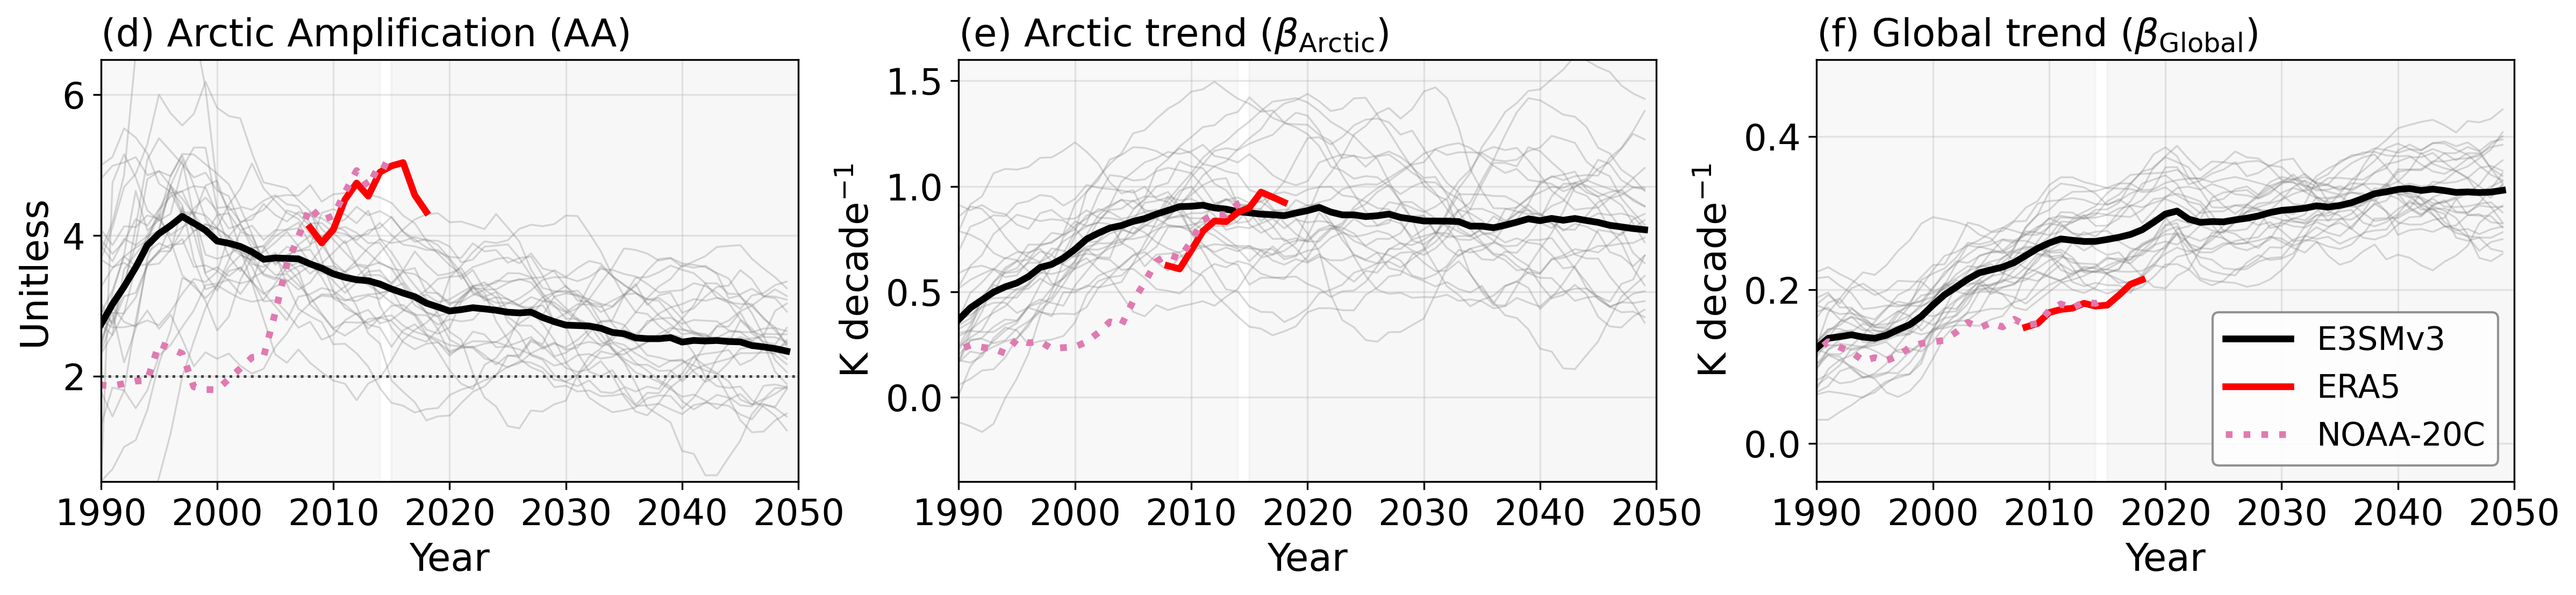

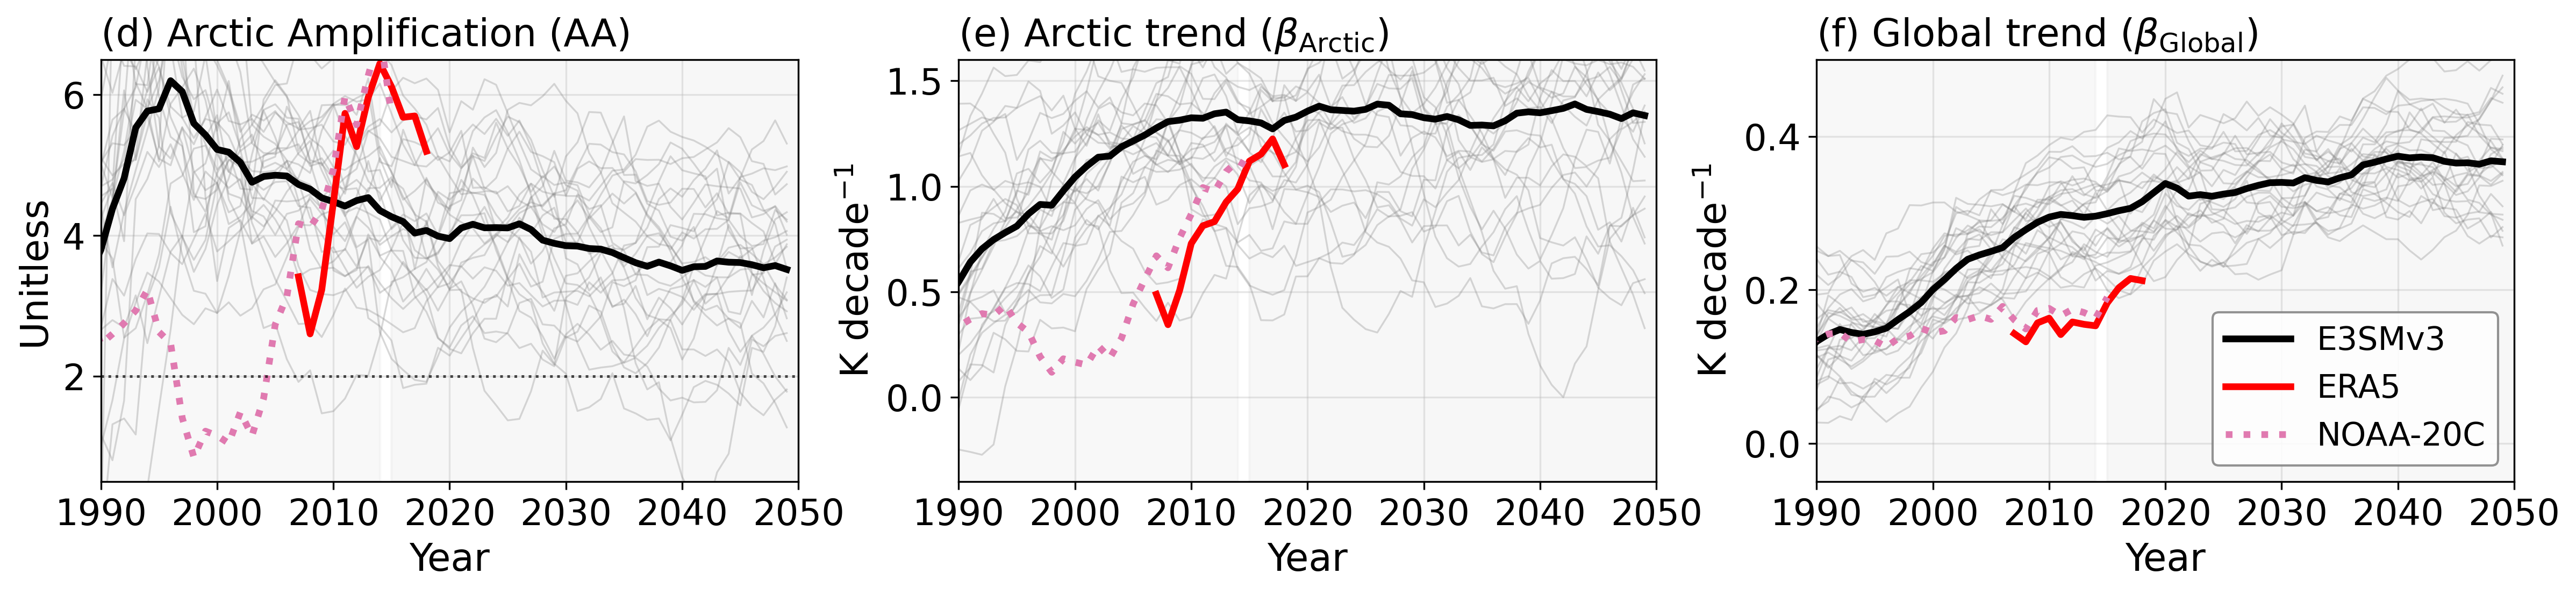

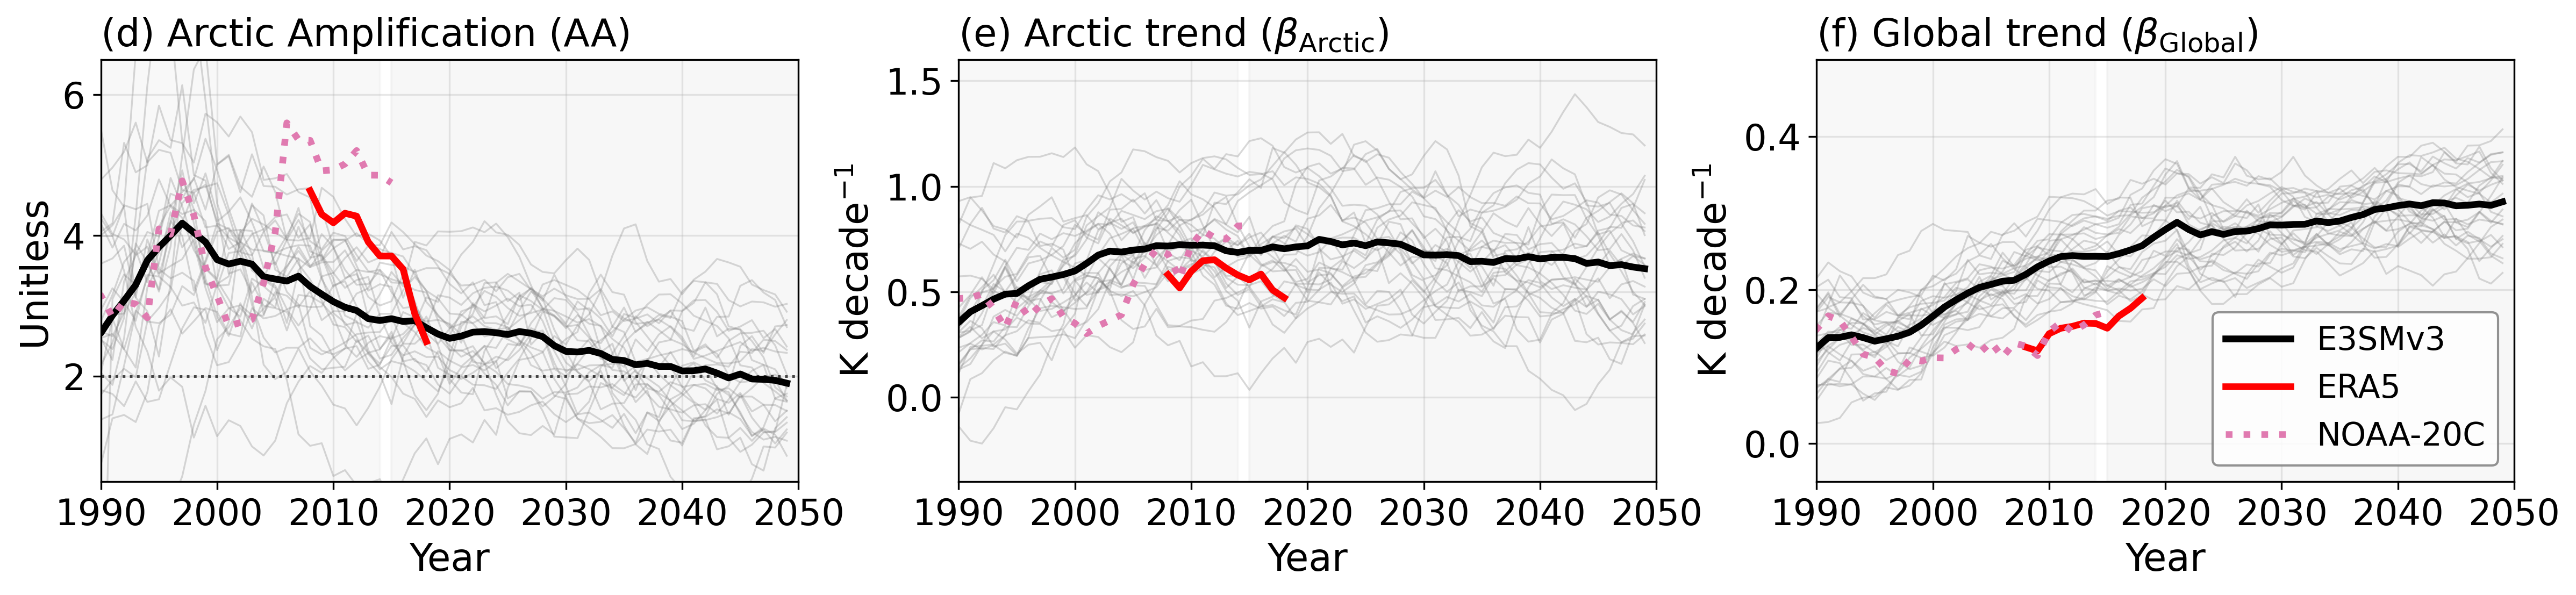

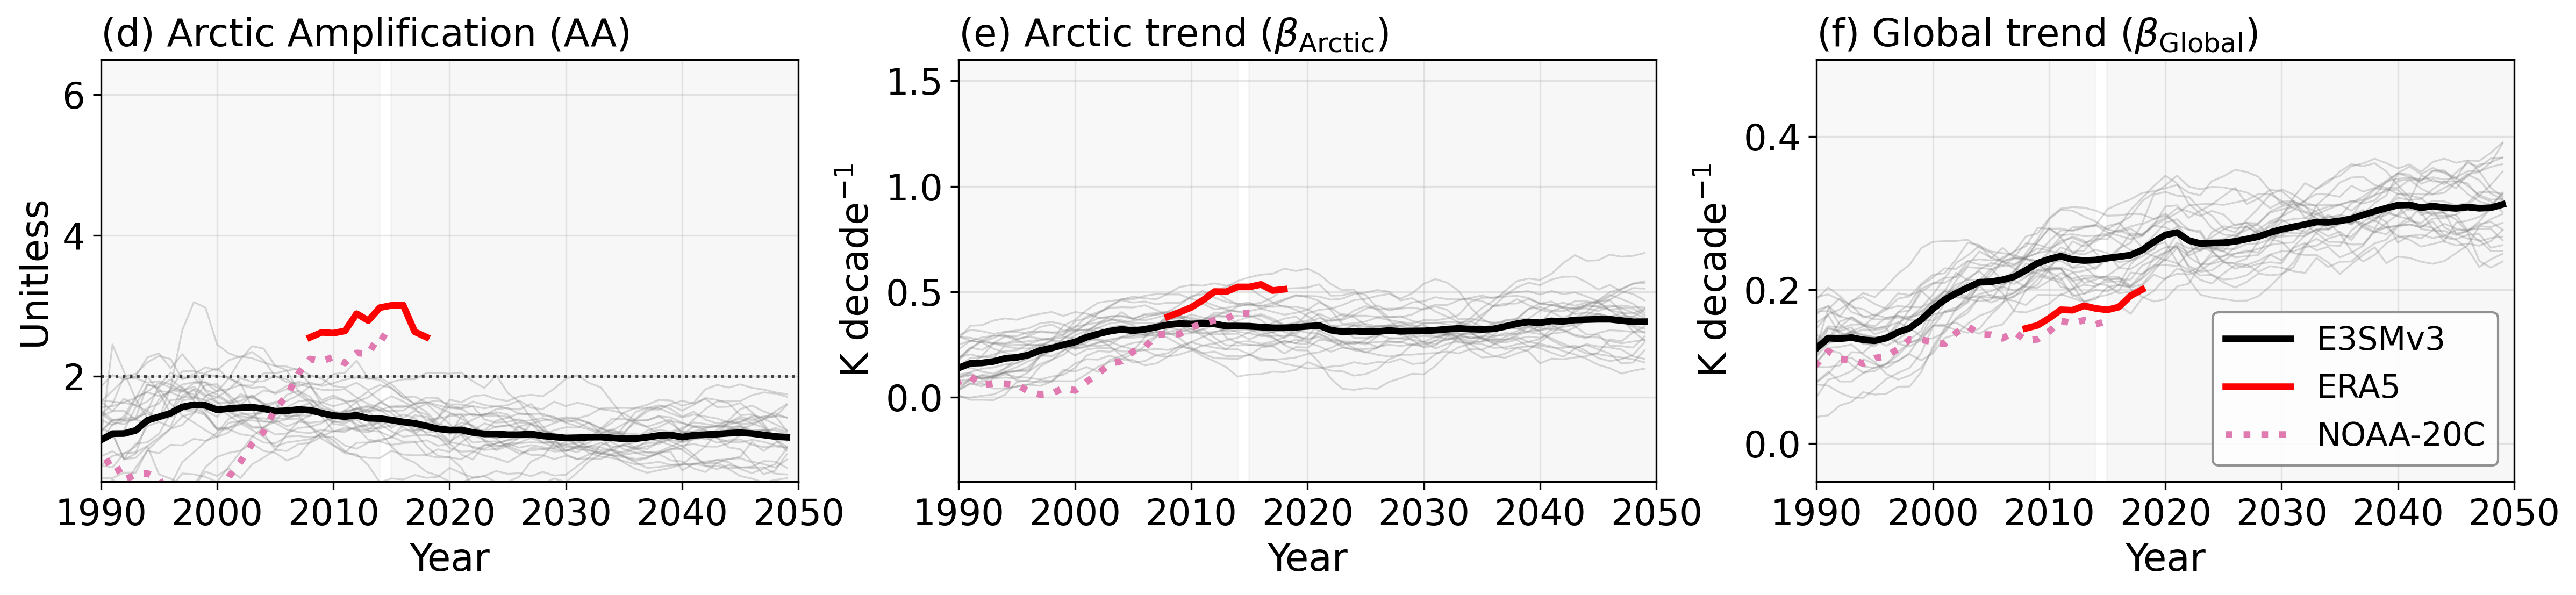

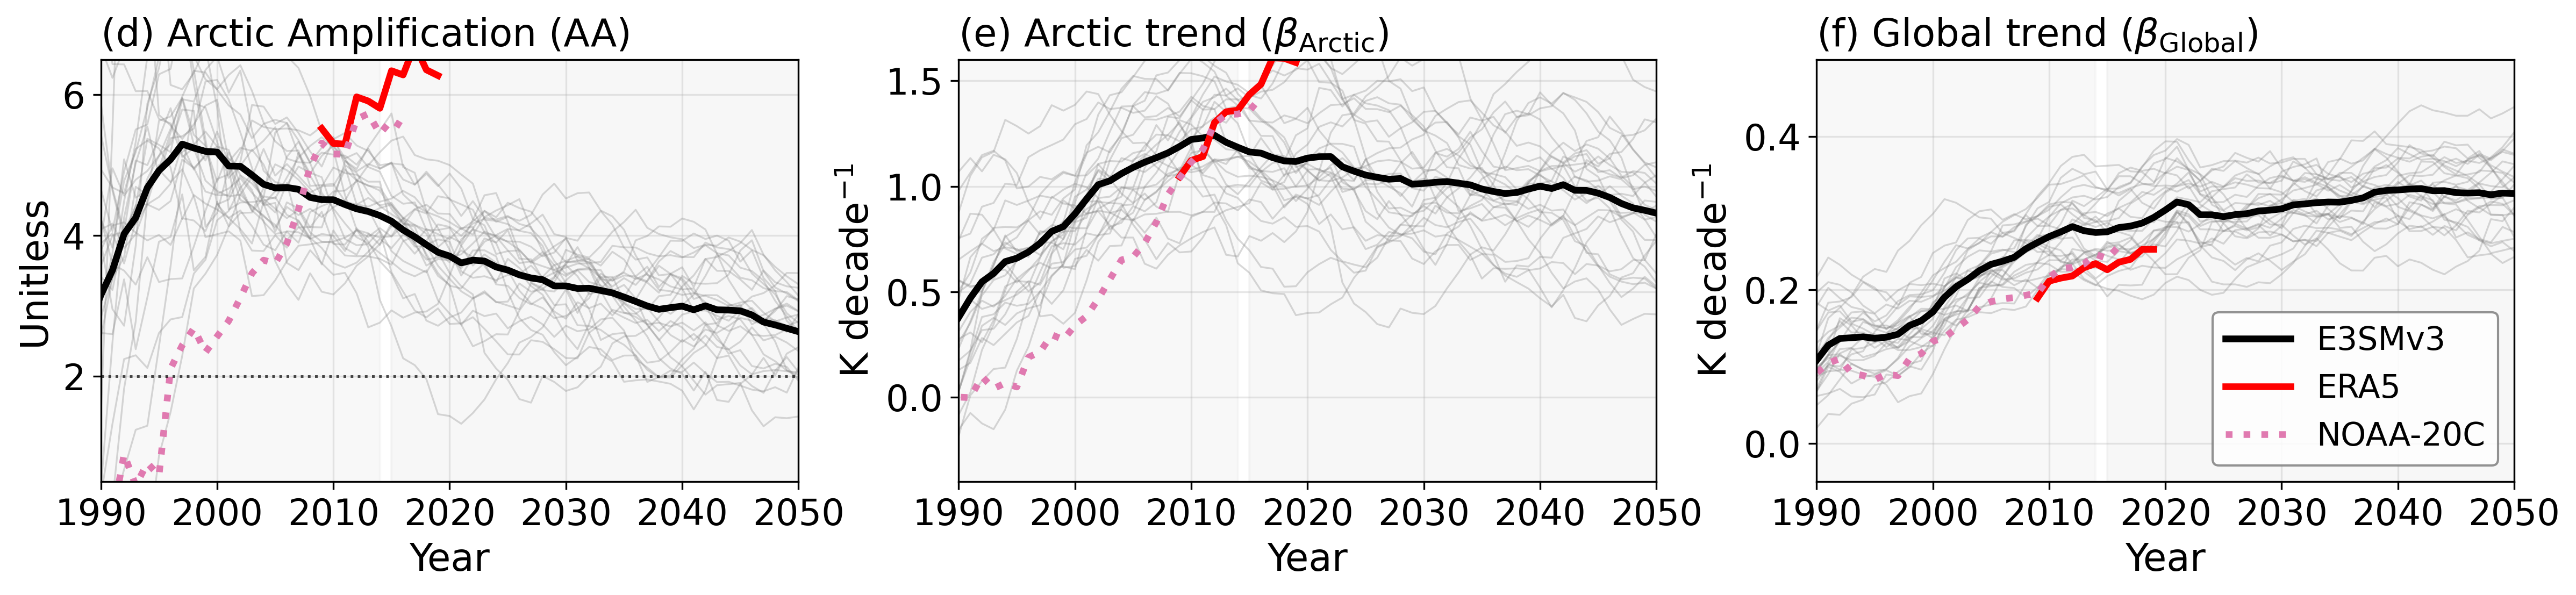

In [51]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = str(FIG_DIR_ROOT)
    os.makedirs(FIG_DIR, exist_ok=True)

    EXPS    = ["ERA5", "NOAA_20C", "E3SMv3-LE"]
    GROUPS  = ["ERA5", "NOAA_20C", "v3.LR.historical"]
    VAR     = "TS"

    # sliding-window axis 1850–2050
    PTARGT  = (1850, 2050)
    SEASONS = ["ANN", "DJF", "MAM", "JJA", "SON"]
    anch = "end"

    # x-axis limits for END-anchored 30-yr window
    xlim = (1990, 2050)

    trend_window   = 30
    figsize        = (16, 4)
    fontz          = 17
    ylim_aa        = (0.5, 6.5)
    ylim_arc       = (-0.4, 1.6)
    ylim_glb       = (-0.05, 0.5)
    
    plotter = ArcticAAPlotter(
        fig_dir=FIG_DIR,
        out_dir=OUT_DIR,
        ptargt=PTARGT,
        trend_window=trend_window,
        trend_anchor=anch,
        var=VAR,
        verbose=True,
        show_ref_line=True,
        ref_value=2.0,
        fontz=fontz,
    )

    # Loop over seasons and generate 3-panel time-series figure
    for SEASON in SEASONS:

        prefix_era5 = f"AA2_{EXPS[0]}_{anch}_ts_{GROUPS[0]}_{VAR}"
        prefix_noaa = f"AA2_{EXPS[1]}_{anch}_ts_{GROUPS[1]}_{VAR}"
        prefix_e3sm = f"AA2_{EXPS[2]}_{anch}_ts_{GROUPS[2]}_{VAR}"

        out_name = f"AA2_timeseries_{SEASON}_ERA5_NOAA_E3SM_30yr_end.pdf"

        plotter.plot_metrics_timeseries_tripanel(
            prefix_era5=prefix_era5,
            prefix_noaa=prefix_noaa,
            prefix_e3sm=prefix_e3sm,
            season=SEASON,
            xlim=xlim,
            ylim_aa=ylim_aa,
            ylim_arc=ylim_arc,
            ylim_glb=ylim_glb,
            figsize=figsize,
            out_name=out_name,
        )
